In [5]:
import pandas as pd

# Load the dataset (semicolon-delimited, latin1 encoding)
df = pd.read_csv("08_nba-free-throws.csv", sep=";", encoding="latin1")

# Keep only relevant columns
df = df[["Player", "Tm", "FT", "G", "GS", "FTA"]]

# Drop "TOT" rows for players who have multiple entries (avoid double-counting)
multi_team = df["Player"].duplicated(keep=False)
df = df[~((df["Tm"] == "TOT") & multi_team)]

# Compress multiple rows per player by summing stats
df = df.groupby("Player", as_index=False)[["FT", "G", "GS", "FTA"]].sum()

# Filter for players with (FTA * G) > 25
df = df[(df["FTA"] * df["G"]) > 25].reset_index(drop=True)

# Compute FT_total, FTA_total, FT%
df["FT_total"] = df["FT"] * df["G"]
df["FTA_total"] = df["FTA"] * df["G"]
df["FT%"] = df["FT_total"] / df["FTA_total"]

print(df)

              Player   FT   G  GS  FTA  FT_total  FTA_total       FT%
0       Aaron Gordon  2.4  73  73  3.7     175.2      270.1  0.648649
1      Aaron Holiday  0.7  78   1  0.8      54.6       62.4  0.875000
2      Aaron Nesmith  1.5  72  47  1.9     108.0      136.8  0.789474
3      Aaron Wiggins  0.7  78   4  0.9      54.6       70.2  0.777778
4         Al Horford  0.4  65  33  0.5      26.0       32.5  0.800000
..               ...  ...  ..  ..  ...       ...        ...       ...
371     Zach Collins  1.8  69  29  2.3     124.2      158.7  0.782609
372      Zach LaVine  3.5  25  23  4.1      87.5      102.5  0.853659
373       Zeke Nnaji  0.7  58   0  1.1      40.6       63.8  0.636364
374  Ziaire Williams  1.2  51  15  1.5      61.2       76.5  0.800000
375  Zion Williamson  5.0  70  70  7.1     350.0      497.0  0.704225

[376 rows x 8 columns]


/var/folders/sd/ffb0jd911vgbr774jlfgplbm0000gn/T/ipykernel_2067/1530431860.py:65: UserWarning: Glyph 138 (\x8a) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 138 (\x8a) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


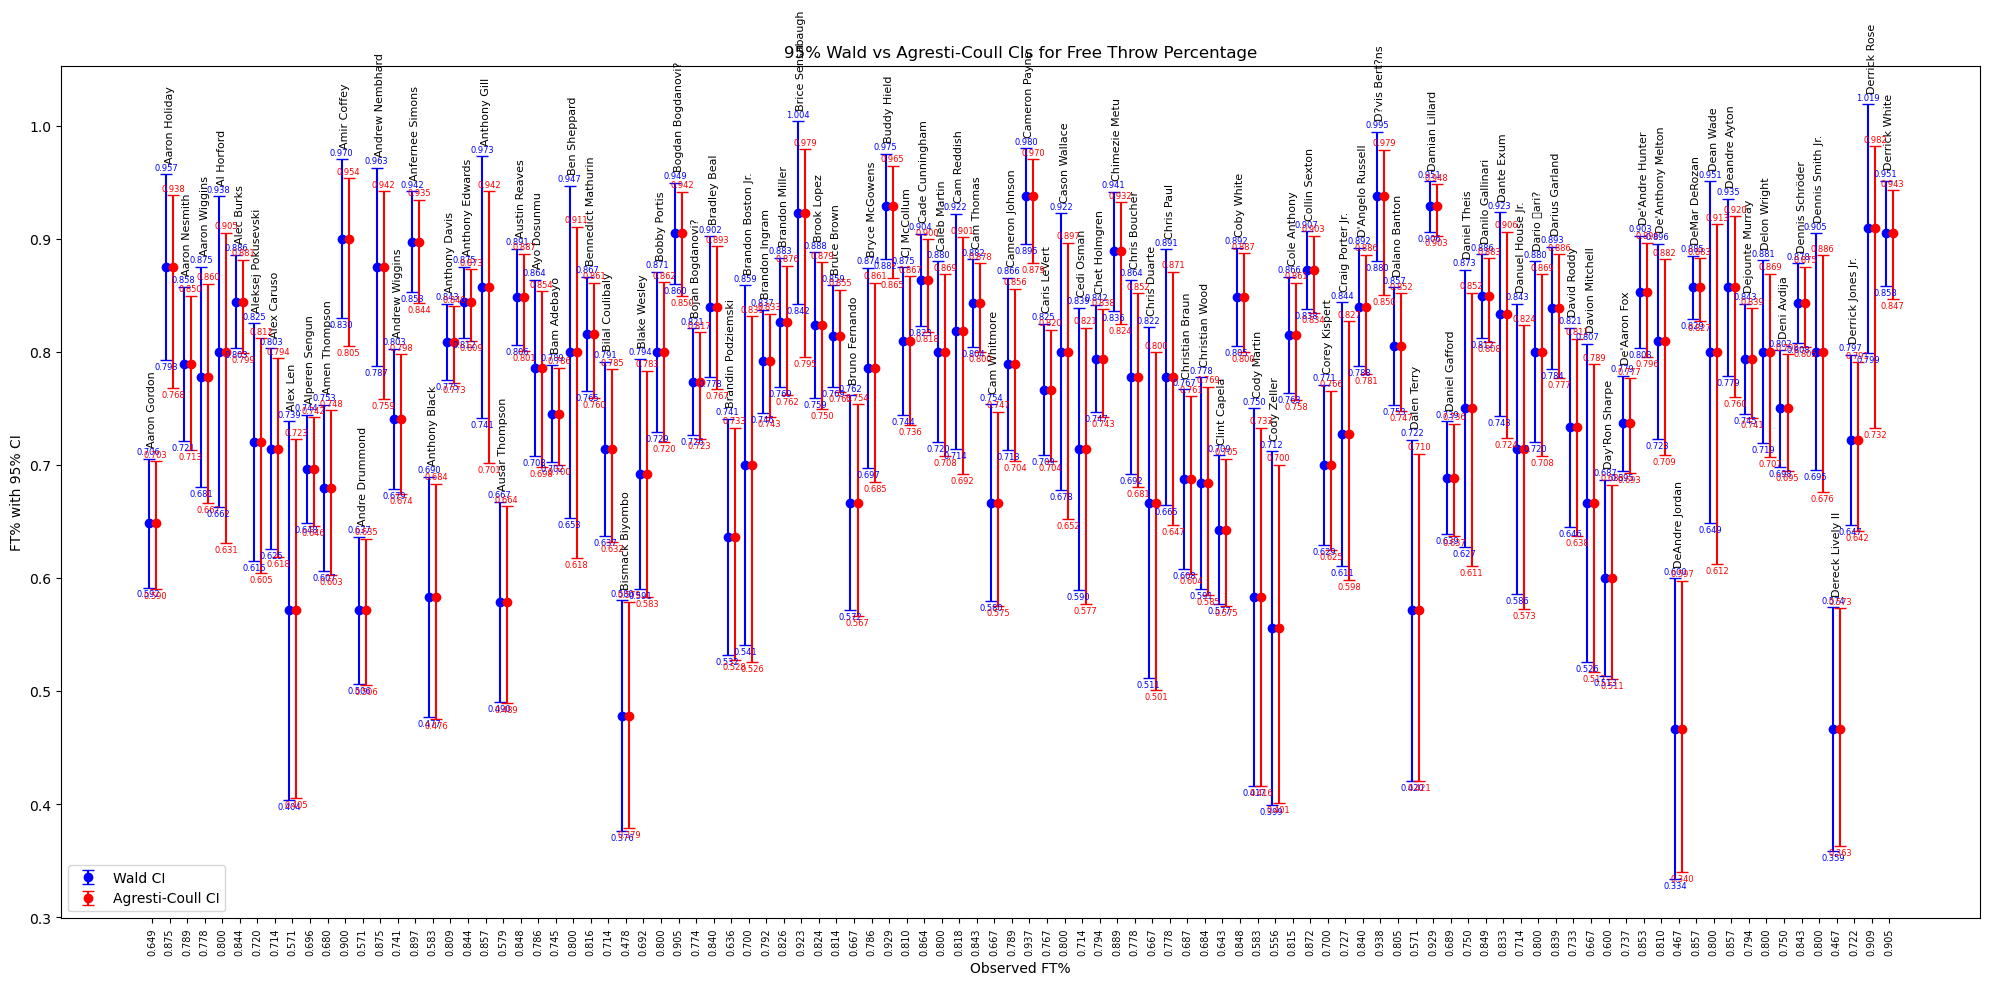

In [8]:
import numpy as np
import matplotlib.pyplot as plt

z = 1.96  # 95% confidence

# Compute Wald CI
p_hat = df["FT%"]
n = df["FTA_total"]

wald_se = np.sqrt(p_hat * (1 - p_hat) / n)
df["Wald_low"] = p_hat - z * wald_se
df["Wald_high"] = p_hat + z * wald_se

# Compute Agresti-Coull CI
n_tilde = n + z**2
p_tilde = (df["FT_total"] + z**2 / 2) / n_tilde
ac_se = np.sqrt(p_tilde * (1 - p_tilde) / n_tilde)
df["AC_low"] = p_tilde - z * ac_se
df["AC_high"] = p_tilde + z * ac_se

# Select 50 players to plot
plot_df = df.head(100).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(20, 10))

x = np.arange(len(plot_df))
offset = 0.2  # horizontal offset to separate the two CIs

# Wald CI (shifted left)
ax.errorbar(
    x - offset, plot_df["FT%"],
    yerr=[plot_df["FT%"] - plot_df["Wald_low"], plot_df["Wald_high"] - plot_df["FT%"]],
    fmt="o", color="blue", capsize=4, label="Wald CI"
)

# Agresti-Coull CI (shifted right)
ax.errorbar(
    x + offset, plot_df["FT%"],
    yerr=[plot_df["FT%"] - plot_df["AC_low"], plot_df["AC_high"] - plot_df["FT%"]],
    fmt="o", color="red", capsize=4, label="Agresti-Coull CI"
)

# Annotate player names above each point
for i, row in plot_df.iterrows():
    ax.text(i, max(row["Wald_high"], row["AC_high"]) + 0.01, row["Player"],
            ha="center", va="bottom", rotation=90, fontsize=8)

# Annotate top/bottom CI values
for i, row in plot_df.iterrows():
    ax.text(i - offset, row["Wald_high"] + 0.002, f"{row['Wald_high']:.3f}",
            ha="center", va="bottom", fontsize=6, color="blue")
    ax.text(i - offset, row["Wald_low"] - 0.002, f"{row['Wald_low']:.3f}",
            ha="center", va="top", fontsize=6, color="blue")
    ax.text(i + offset, row["AC_high"] + 0.002, f"{row['AC_high']:.3f}",
            ha="center", va="bottom", fontsize=6, color="red")
    ax.text(i + offset, row["AC_low"] - 0.002, f"{row['AC_low']:.3f}",
            ha="center", va="top", fontsize=6, color="red")

ax.set_xticks(x)
ax.set_xticklabels([f"{v:.3f}" for v in plot_df["FT%"]], rotation=90, fontsize=7)
ax.set_xlabel("Observed FT%")
ax.set_ylabel("FT% with 95% CI")
ax.set_title("95% Wald vs Agresti-Coull CIs for Free Throw Percentage")
ax.legend()
plt.tight_layout()
plt.show()


#My observations: The AC CI is always lower than the Wald CI. I suppose this means that 

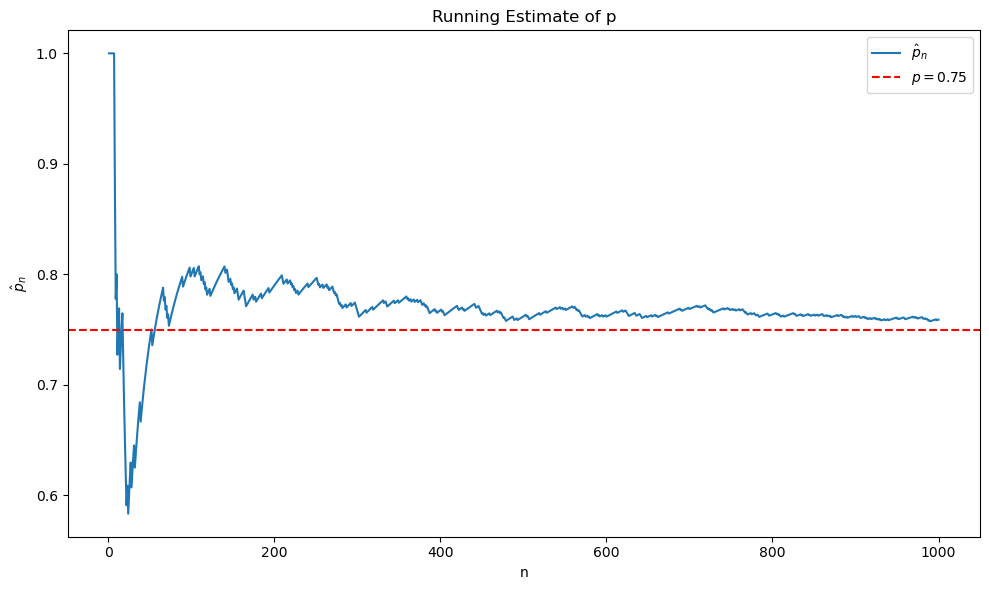

In [9]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)  # for reproducibility

p = 0.75
n_max = 1000

# Simulate one sequence of Bernoulli(p) trials
X = np.random.binomial(1, p, size=n_max)

# Compute running estimate p_hat_n
p_hat = np.cumsum(X) / np.arange(1, n_max + 1)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(np.arange(1, n_max + 1), p_hat, label=r"$\hat{p}_n$")
ax.axhline(p, color="red", linestyle="--", label=r"$p = 0.75$")
ax.set_xlabel("n")
ax.set_ylabel(r"$\hat{p}_n$")
ax.set_title("Running Estimate of p")
ax.legend()
plt.tight_layout()
plt.show()

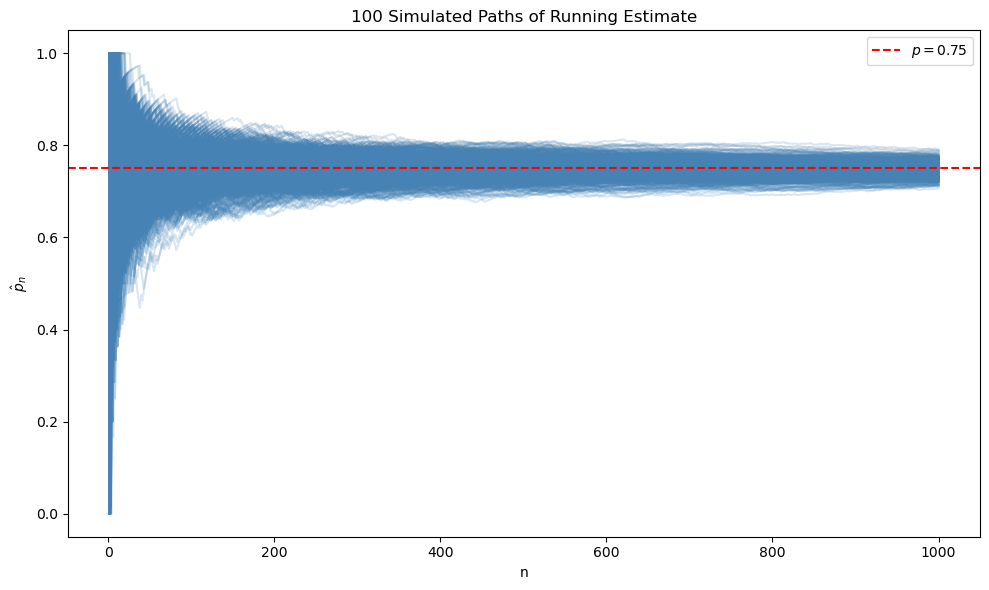

In [14]:
n_sims = 1000

fig, ax = plt.subplots(figsize=(10, 6))

for i in range(n_sims):
    X_i = np.random.binomial(1, p, size=n_max)
    p_hat_i = np.cumsum(X_i) / np.arange(1, n_max + 1)
    ax.plot(np.arange(1, n_max + 1), p_hat_i, color="steelblue", alpha=0.2)

ax.axhline(p, color="red", linestyle="--", label=r"$p = 0.75$")
ax.set_xlabel("n")
ax.set_ylabel(r"$\hat{p}_n$")
ax.set_title("100 Simulated Paths of Running Estimate")
ax.legend()
plt.tight_layout()
plt.show()

#Any vertical slice represents the observed distribution of sample means at n trials. As n increases, the variance of the distribution falls. This is proven by the CLT.

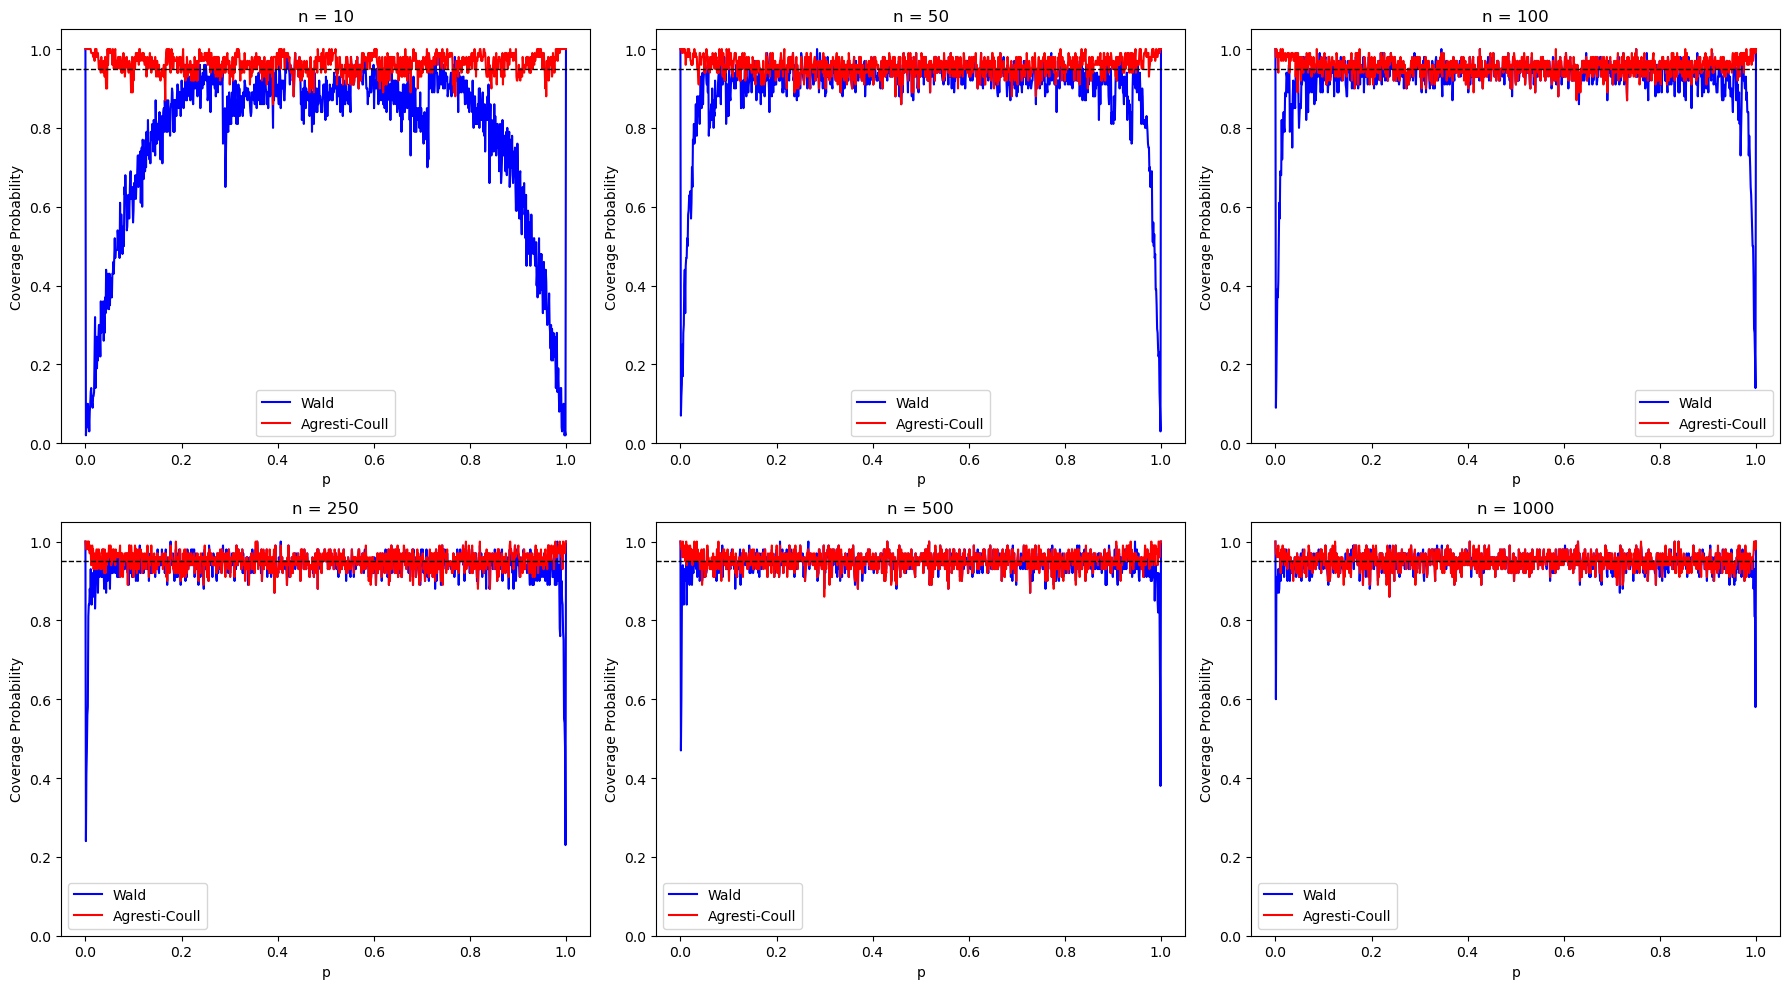

In [15]:
import numpy as np
import matplotlib.pyplot as plt

z = 1.96
M = 100
n_values = [10, 50, 100, 250, 500, 1000]
p_grid = np.linspace(0, 1, 1000)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, n in enumerate(n_values):
    wald_coverage = np.zeros(len(p_grid))
    ac_coverage = np.zeros(len(p_grid))

    for j, p in enumerate(p_grid):
        # Generate M simulations of n free throws ~ Binomial(n, p)
        x = np.random.binomial(n, p, size=M)
        p_hat = x / n

        # Wald CI
        wald_se = np.sqrt(p_hat * (1 - p_hat) / n)
        wald_low = p_hat - z * wald_se
        wald_high = p_hat + z * wald_se
        wald_coverage[j] = np.mean((wald_low <= p) & (p <= wald_high))

        # Agresti-Coull CI
        n_tilde = n + z**2
        p_tilde = (x + z**2 / 2) / n_tilde
        ac_se = np.sqrt(p_tilde * (1 - p_tilde) / n_tilde)
        ac_low = p_tilde - z * ac_se
        ac_high = p_tilde + z * ac_se
        ac_coverage[j] = np.mean((ac_low <= p) & (p <= ac_high))

    ax = axes[idx]
    ax.plot(p_grid, wald_coverage, label="Wald", color="blue")
    ax.plot(p_grid, ac_coverage, label="Agresti-Coull", color="red")
    ax.axhline(0.95, color="black", linestyle="--", linewidth=1)
    ax.set_title(f"n = {n}")
    ax.set_xlabel("p")
    ax.set_ylabel("Coverage Probability")
    ax.set_ylim(0, 1.05)
    ax.legend()

plt.tight_layout()
plt.show()


#Within every graph: At very low 'true' probabilities, the 95% Wald confidence interval contains the true p a very low proportion of the time.

#Across graphs: As the sample size increases, the success rate of the Wald CI containing the true p at low p increases.